# Linear Systems and Least Squares 

## Overview

Further exploring the theme of linear systems, in this notebook I will continue to learn about how to overcome the issue of having more equations than unknowns with our linear equation from Project 2. 

### Why?

In Project 2, I encountered a linear model expressed as $\hat{y} = Xw + b$.  We used this to build a linear predictor that could, using weights and biases, take 2 different features and 'predict' what the likely output should be.  

This allowed us to take multiple rows of data, multiple target variables, and determine a prediction.  However, this model is simplistic in that it assumes every equation can be satisfied simultaneously.  In the real world there is likely no $w$ that will satisfy all equations exactly. This means we shift from trying to find a $w$ that satisfies all equations exactly, to finding a $w$ that makes $Xw$ as close to $\hat{y}$ as possible, where $\hat{y}$ represents the true target values we observed, and $Xw$ is our model's prediction.  This is where we enter into least squares, and the normal equation.  

This notebook is useful because it takes an important concept from the previous chapter and pushes it further towards the utility that it has in the real world.  I plan on encountering some new concepts and solving problems that help me cement my fundamental understanding of ML math.  

### Constraints

Same as before: basic Python.  Until I've written the code and understand what is being done at a basic level, I will not use any special libraries.  
### Steps

1. Recap on Project 2 - Matrices and Linear Models
2. Introduce least squares
3. Deriving the normal equation
4. Solve the normal equation as a linear system
5. Apply these tools to regression
6. Inspect and interpret

## Project 2 Recap - Matrices and Linear Models

In Project 2, rows represented examples and columns represented features.  This is ML language, so I'll use them interchangeably throughout.  

That gets us back to a topic we briefly touched on:  Matrix-Vector multiplication (Matvec). Matvec is the core operation behind $\hat{y} = Xw$, which is what we'll be building on.  

### Matvec

It's exactly what it sounds like: multiplying a matrix by a single vector.  
Matvec is expressed as $Av = b$ where $A$ is the matrix, $v$ is the vector, and $b$ is the resulting vector.  

You'll recall that one limiting rule for matvec multiplication is that if the length of the vector $v$ does not match the number of columns of matrix $A$, we can't multiply them together.  

In [1]:
# Quick refresh on Matvec math
A = [[2, 7],
     [3, 8]]

v = [2, 3]

# Dot product multiplication is a component of matvec multiplication
def dot_product(v, w):
    if len(v) != len(w):
        raise ValueError('Vectors are not of equal length')
    product = 0
    for i in range(len(v)):
        product += v[i] * w[i]
    return product
    
def matvec(A, v):
    rows, cols = len(A), len(A[0])
    if len(v) != cols:
        raise ValueError(f'Shapes are incompatible.  A is {rows} x {cols}, v has length {len(v)}')

    new_vec = []
    for row in A:
        new_vec.append(dot_product(row, v))
    return new_vec

print(f' For a right sized matrix: {matvec(A, v)}')

 For a right sized matrix: [25, 30]


In the $Av = b$ format, a **column vector** is always produced, although Python represents it as a flat list.  A library like `NumPy` is necessary to make that orientation obvious.  

Orientation matters because otherwise this multiplication would not work:  $X$ is $m \times n$ (rows x columns), $w$ must be $n \times 1$, so the result is $m \times 1$.  

Let's look again at the linear equation we introduced in Notebook 2: 
$$
\hat{y} = Xw + b
$$

Breaking it down:  

- Individual prediction values $\hat{y}$ are column vectors
- A single example $x_i$ is a row vector containing all its feature values
- Weights $w$ are column vectors 

What ties these values together is the `transpose()` function.  This function enables us to change the orientation of a row vector to a column vector and vice versa.  The transpose function makes shapes compatible so we can multiply our features $x$ by our weights $w$ given that they are different types of vectors.  This plays an essential role in the Normal Equation.  See below for code definition:

In [2]:
# Shape of Matrix
def shape_matrix(M):
    if len(M) == 0:
        return (0, 0)
    return (len(M), len(M[0]))

def shape_vector(v):
    return (len(v))

# Transpose Function
def transpose(M):
    rows, cols = shape_matrix(M) # Leverage existing shape function
    return [[M[r][c] for r in range(rows)] for c in range(cols)]

## Introducing Least Squares

The reduction of error is the central objective in ML because it increases the likelihood that a model's predictions are more accurate.  In the linear model we reviewed before, our goal was to reduce the difference between actual and predicted values.  We did that by manually manipulating the weights $w$ and biases $b$ in our model to illustrate how they shape predictions.   

So how could we minimize that error and simultaneously amplify the penalty of large errors?  We do this through least squares.

**Least Squares** refers to the process of squaring the difference between predicted and actual values.  This will accomplish two things:  eliminating negative values, and amplifying larger errors more heavily than tiny ones.  We would then sum all those squared residual errors together and find the weight value $w$ that makes the sum as small as possible. 

In formula terms we express the squared residual as: 
$$
(\hat{y_i} - y_i)^2
$$
We would do this across all examples $x_i$ and then minimize that total.  The total would be represented as $||Xw - y||^2$, or the **least squares equation**.  

## Deriving the Normal Equation

Taking the concept of least squares further, the **normal equation** seeks to minimize the loss of the **least squares equation** by finding where its derivative with respect to $w$ equals zero.  

The result is the following, known as the **normal equation**:
$$
X^TXw = X^Ty
$$

Solving for $w$ produces this:
$$
w = (X^TX)^{-1}X^Ty
$$
Where $X^TX$ is a matrix, $X^Ty$ is a vector, and $w$ is unknown. 

Getting back to the core objective:  the **normal equation** is useful because it provides us with a value $w$ that produces the best possible predictions given our dataset.  

## Solving the Normal Equation as a Linear System

In the previous section we were left with the question:  "How do we solve for $w$?"  

The normal equation is a square linear system (a system of equations where the number of unknowns equals the number of equations).  $X^TX$ is always square regardless of the shape of the matrix $X$. 

Logically $X$ is $m \times n$, $X^T$ is $n \times m$, so $X^TX$ is $n \times n$.  $n$ equations, $n$ unknowns.  

A tool we can use to solve square linear systems like this and determine $w$ is **Gaussian Elimination**.  

**Gaussian Elimination** uses something almost everyone learned in basic Algebra, linear combinations, to combine rows of linear equations with addition or subtraction.  By doing this you can simplify equations and try to eliminate unknowns. 

With Gaussian elimination, we use multiplication to try to get a zero in front of one variable.  

We can take 2 linear equations like these:

$$
\begin{aligned}
2x + 3y = 8 \\ 
4x + y = 6
\end{aligned}
$$

We can then multiply the 1st equation by 2 (to match the coefficient of $x$ in the 2nd equation):
$$
4x + 6y = 16
$$

Then we can subtract that 1st equation from the 2nd like so:
$$
\begin{array}{r r r r r}
& 4x & + & y & = 6 \\
-&(4x & + & 6y & = 16) \\
\hline 
& & & -5y & = -10 \\
& & & y & = 2
\end{array}
$$

We can then back-substitute the learned $y$ value into the original equation:  
$$
\begin{aligned}
2x + 3(2) = 8 \\
2x = 2 \\
x = 1
\end{aligned}
$$

Now we will take this manual math and convert it into plain Python code without using `NumPy`:


In [3]:
# Represents the x & y values on the left side of the equation
A = [[2, 3],
     [4, 1]]
# Represents the numerical values on the right side of the equation
b = [8, 6]

# Augment Matrix operation will attach each element of b  
# as an extra column onto the corresponding row of A
def augment_matrix(A, b):
    if len(b) != len(A):
        raise ValueError('Shapes are not compatible')
    new_mat = []
    for i, v in enumerate(A):
        new_row = A[i][:] # Avoids modifying A while still getting val
        new_row.append(b[i]) 
        new_mat.append(new_row) 
    return new_mat

print(augment_matrix(A, b))

[[2, 3, 8], [4, 1, 6]]


In [4]:
# Gaussian elimination is the process of matching coefficients to get them equal to 0
def gaussian_elimination(A): 
    for i in range(len(A) - 1): # Should only go up to 2nd to last row
        # Start with pivot coef (column value in 1st row)
        pivot = A[i][i] 
        for j in range(i+1, len(A)): # Evaluate next row(s)
            # Match with coef in next row
            coef = A[j][i]
            multiplier = coef / pivot # Need this to match coefficients
            for k in range(len(A[j])): # Iterate through all values in 2nd row
                A[j][k] = A[j][k] - multiplier * A[i][k] # Set second row values equal to current value minus the applied multiplier to the 1st row pivot
    return A
print(gaussian_elimination(augment_matrix(A, b)))          

[[2, 3, 8], [0.0, -5.0, -10.0]]


In [5]:
def back_substitution(A):
    solutions = [0] * len(A) # Sized to length of matrix filled with 0s
    solutions[-1] = A[-1][-1] / A[-1][-2] # Store known solution
    for i in reversed(range(len(A) - 1)): # We have to start from the 2nd to last row
        known_sum = 0
        for j in range(i+1, len(A)): # J iterates over columns to the right of pivot, i.e. already solved variables
            known_sum += A[i][j] * solutions[j] # Summing values of already known variables to current row equation
        solutions[i] = (A[i][-1] - known_sum) / A[i][i] # Solving for unknown at position i after subtracting known contributions
    return solutions
        
print(back_substitution(gaussian_elimination(augment_matrix(A, b)))) 


[1.0, 2.0]


In [6]:
# Bundling it all up in one function
def solve_linear_system(A, b):
    augmented_mat = augment_matrix(A, b)
    row_reduction = gaussian_elimination(augmented_mat)
    solution = back_substitution(row_reduction)
    return solution
print(solve_linear_system(A, b))

[1.0, 2.0]


### Recap of Function Processes

I'm a very visual person and struggle to see these in my head unless I can map out every step.  Below is a flow chart to better understand exactly what just happened:

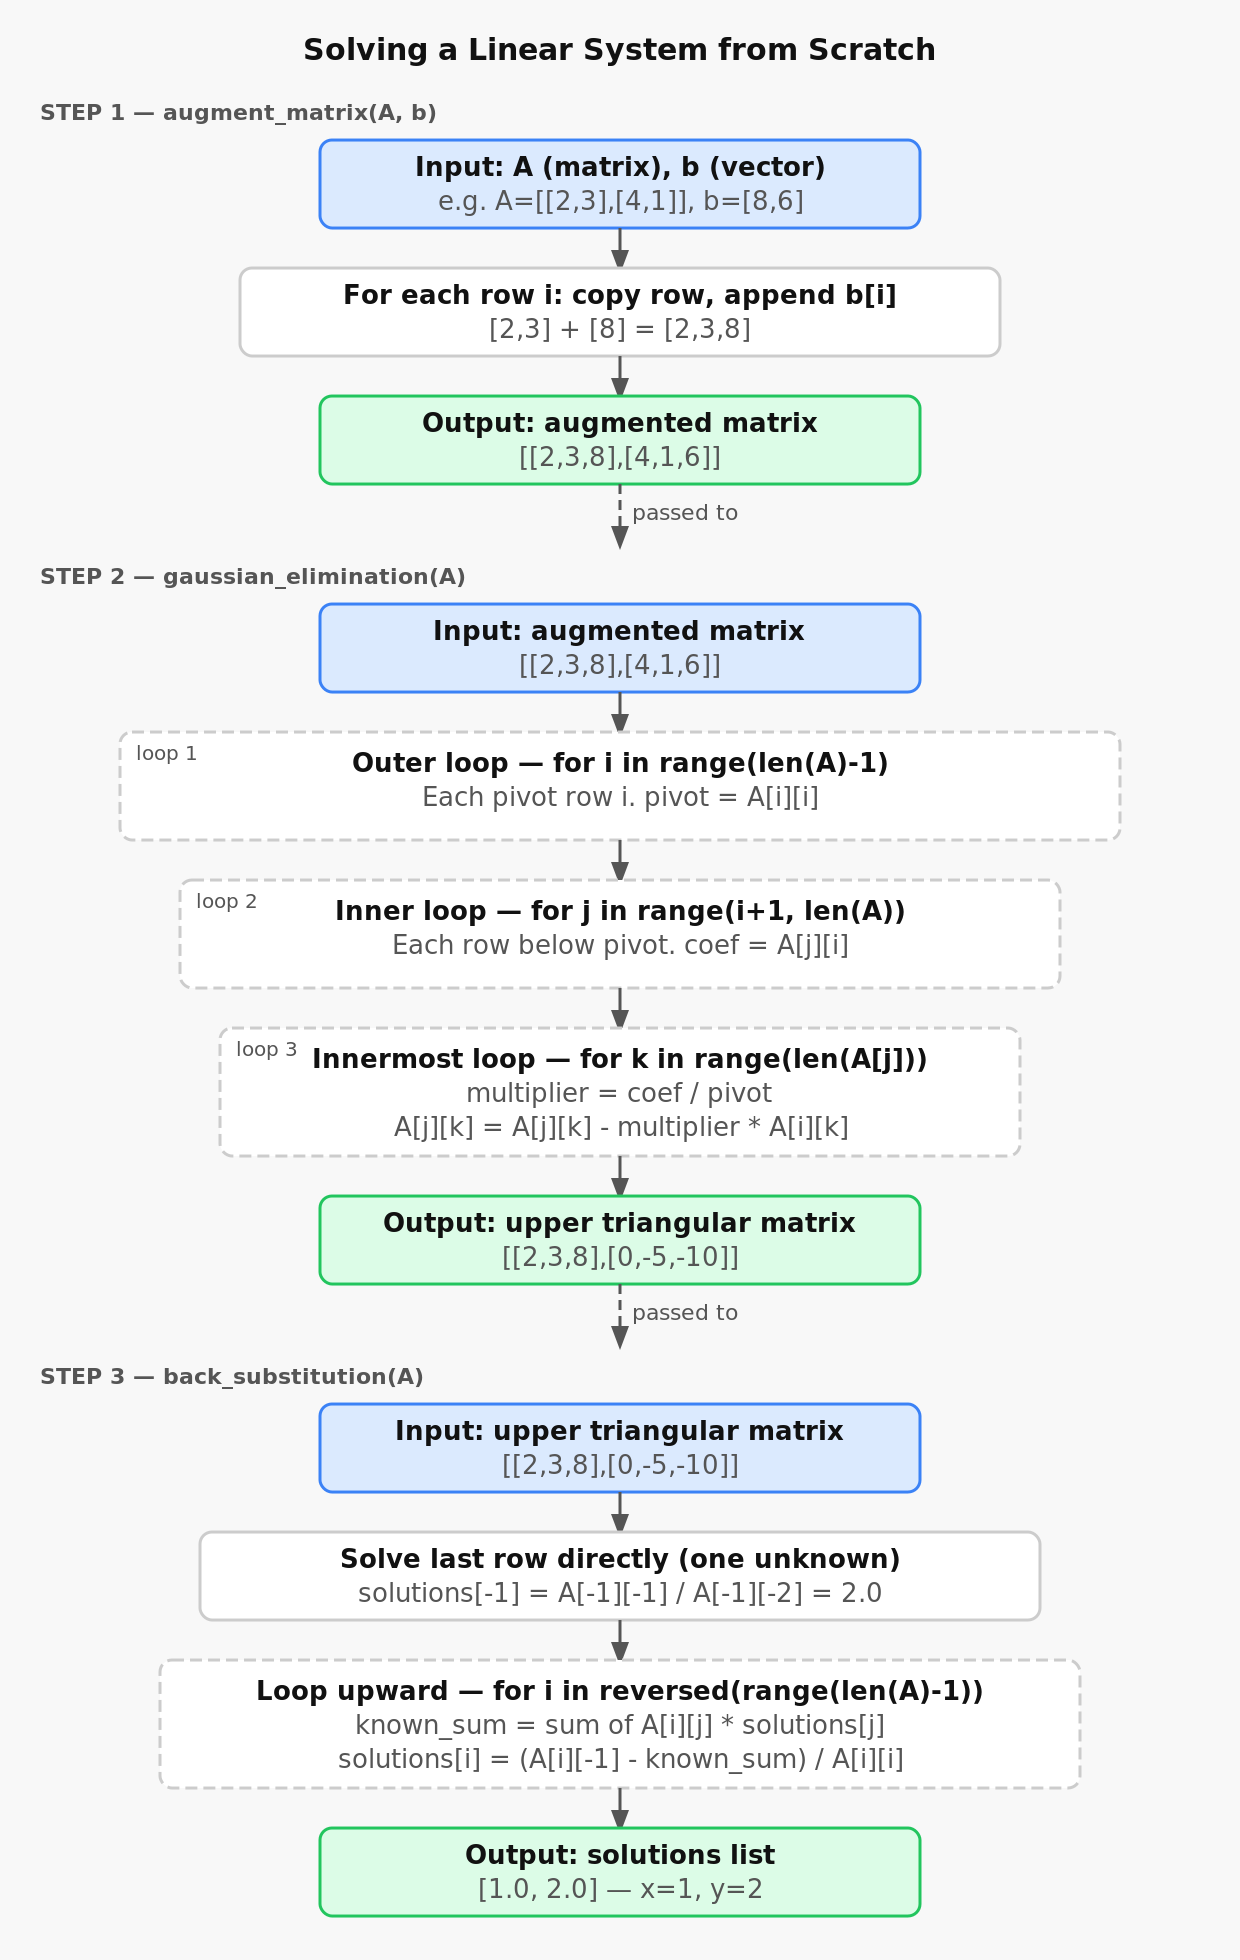

### Applying Solver to the Normal Equation

Finally, we will take the `solve_linear_system()` function we created above and apply it to the **normal equation**:
$$
X^TXw = X^Ty
$$
To make this more familiar, we can look at $X^TX$ as A and $X^Ty$ as b.  

This time we'll use a slightly larger matrix (more examples and features) and a longer set of target values based on the scenario from Project 2.  

In [7]:
# Establishing X and y
# Columns left => right 
# | Bias | Pizza | Sleep
X = [[1.0, 4.0, 6.0],
     [1.0, 3.0, 8.0],
     [1.0, 5.0, 7.0],
     [1.0, 3.0, 6.0],
     [1.0, 2.0, 7.0],
     [1.0, 3.0, 5.0]]

# Mile Times
y_true = [5.5, 5.0, 5.8, 5.5, 4.9, 5.7]

# Matmul, needed for this operation
def matmul(A, B):
    rows_A, cols_A = len(A), len(A[0])
    rows_B, cols_B = len(B), len(B[0])

    if cols_A != rows_B:
        raise ValueError(f'Matrices are incompatible.  A is {rows_A} x {cols_A}, B is {rows_B} x {cols_B}')
    
    B_T = transpose(B) # Leverage existing transpose function
    new_mat = []
    for row in A:
        new_row = []
        for col in B_T:
            new_row.append(dot_product(row, col)) # Leverage existing dot product function
        new_mat.append(new_row)
    return new_mat

def fit_normal_equation(A, b):
    transposed = transpose(A)
    matmulled = matmul(transposed, A)
    matveced = matvec(transposed, b)
    result = solve_linear_system(matmulled, matveced)
    return result

w = fit_normal_equation(X,y_true)
print(w)
    


[5.943181818181853, 0.26249999999999596, -0.21818181818182128]


We've received some seemingly plausible responses from running this: a *bias of 5.94* (baseline time with all features at 0), a *0.26 pizza coefficient* (each additional slice adds 0.26 minutes to mile time), and a *-0.22 sleep coefficient* (each additional hour of sleep reduces mile time by 0.22 minutes).  

To test this, we can use our linear prediction model we created in Project 2.  This is all starting to come together!

In [8]:
# Simple linear prediction 
# Unlike our prediction model from Project 2, bias is baked in here
# so we can drop it and use simple matvec
def predict(X, w):
    y_preds = matvec(X, w)
    return y_preds

residuals = [] # So we can store residual error
y_preds = predict(X, w)
for x_i, y_t, y_p in zip(X, y_true, y_preds):
    residuals.append(y_t - y_p)
    print(f'X = {x_i}, true = {y_t}, pred = {y_p}, residual = {y_t - y_p}')


X = [1.0, 4.0, 6.0], true = 5.5, pred = 5.684090909090909, residual = -0.18409090909090864
X = [1.0, 3.0, 8.0], true = 5.0, pred = 4.985227272727271, residual = 0.014772727272728936
X = [1.0, 5.0, 7.0], true = 5.8, pred = 5.728409090909084, residual = 0.07159090909091592
X = [1.0, 3.0, 6.0], true = 5.5, pred = 5.421590909090913, residual = 0.0784090909090871
X = [1.0, 2.0, 7.0], true = 4.9, pred = 4.940909090909097, residual = -0.040909090909096335
X = [1.0, 3.0, 5.0], true = 5.7, pred = 5.639772727272735, residual = 0.060227272727265024


To review how well this fits, we can evaluate the MSE using the residual error (`residuals`) we collected in the above code:

In [9]:
# Determining Mean Squared Error (MSE)
mse = sum(r**2 for r in residuals) / len(residuals)
print(mse)    

0.00844696969696966


## Inspect and Interpret

We've achieved an **MSE** of *~0.008*, which means that the model fits the data very well.  However, this is an incredibly small, linear dataset with a small number of both examples and features.  In a real-world scenario, we'd want to have thousands (or even millions!) of records to build a better and more capable model.  

What's more important is the knowledge we've gained building this from scratch.  

We've taken matrix foundations from Project 2 and used them to better understand processes like `gaussian_elimination` and `back_substitution` to solve the normal equation as a linear system using `fit_normal_equation`.  We were able to show how everything combined could predict values using `predict` and then determine the residual error of that prediction.  Pretty cool!

In the next notebook we'll explore Gradient Descent for scalars, which opens the door to one of the most important concepts in ML.  

## References

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep learning. MIT Press.